# 01 – Análisis Exploratorio de Datos (EDA)
**Proyecto:** Sistema de Ventas Retail — Predicción de Devoluciones y Monto de Venta  
**Asignatura:** SCY1101 – Programación para la Ciencia de Datos  
**Evaluación:** Parcial N°2

---

## Objetivos del Notebook
1. Cargar y entender los cuatro datasets del proyecto (clientes, ventas, productos, devoluciones).
2. Detectar y documentar problemas de calidad: nulos, duplicados, errores de codificación y formatos mixtos.
3. Aplicar limpieza profunda mediante el módulo `src/data_preprocessing.py`.
4. Construir el dataset maestro unificado para ML.
5. Explorar distribuciones, correlaciones y patrones clave para orientar el modelado.

---


## 1. Importaciones y Configuración

In [1]:
import sys
import os
import warnings
warnings.filterwarnings('ignore')

# Agregar src al path
sys.path.insert(0, os.path.join('..', 'src'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from data_preprocessing import (
    cargar_datos_raw,
    limpiar_clientes,
    limpiar_productos,
    limpiar_ventas,
    limpiar_devoluciones,
    construir_dataset_ml,
    pipeline_completo,
)

# Estilo de gráficos
sns.set_theme(style='whitegrid', palette='Set2', font_scale=1.1)
FIGSIZE = (12, 5)
SEED = 42

print("✓ Librerías importadas correctamente")
print(f"  Pandas v{pd.__version__} | NumPy v{np.__version__}")


✓ Librerías importadas correctamente
  Pandas v3.0.3 | NumPy v2.4.5


---
## 2. Carga de Datos Raw
Leemos los cuatro archivos originales antes de cualquier transformación para documentar el estado inicial.


In [2]:
raw = cargar_datos_raw()
clientes_raw    = raw['clientes']
ventas_raw      = raw['ventas']
productos_raw   = raw['productos']
devoluciones_raw = raw['devoluciones']

resumen_raw = pd.DataFrame({
    'Dataset':    ['Clientes', 'Ventas', 'Productos', 'Devoluciones'],
    'Filas':      [len(df) for df in raw.values()],
    'Columnas':   [df.shape[1] for df in raw.values()],
    'Nulos tot.': [df.isnull().sum().sum() for df in raw.values()],
    'Duplicados': [df.duplicated().sum() for df in raw.values()],
})
print(resumen_raw.to_string(index=False))


     Dataset  Filas  Columnas  Nulos tot.  Duplicados
    Clientes    309         7         105           9
      Ventas   1030         8         402          30
   Productos    206         7          72           6
Devoluciones    154         5          36           4


In [3]:
clientes_raw

,id_cliente,nombre,email,region,ciudad,fecha_registro,segmento
0,NaN,CristÃ³bal Silva MuÃ±oz,cristÃ³bal.silva@gmail.com,Los Lagos,Osorno,2020-01-01,Regular
1,2.0,Fernanda GarcÃ­a HernÃ¡ndez,fernanda.garcÃ­a@outlook.com,Coquimbo,La Serena,2020-01-03,Regular
2,3.0,AndrÃ©s Contreras Soto,NaN,O'Higgins,Rengo,2020-01-05,Regular
3,NaN,Natalia Tapia Rojas,natalia.tapia@gmail.com,Los Lagos,Osorno,07/01/2020,VIP
4,5.0,JosÃ© Soto Fuentes,josÃ©.soto@gmail.com,BiobÃ­o,ConcepciÃ³n,2020-01-09,Premium
...,...,...,...,...,...,...,...
304,276.0,Marcela Bravo Rojas,marcela.bravo@gmail.com,Metropolitana,Santiago,2021-07-04,Nuevo
305,2.0,Fernanda GarcÃ­a HernÃ¡ndez,fernanda.garcÃ­a@outlook.com,Coquimbo,La Serena,2020-01-03,Regular
306,88.0,Ana Flores Soto,ana.flores@gmail.com,Los Lagos,Puerto Montt,23/06/2020,Regular
307,287.0,Daniela Flores GonzÃ¡lez,daniela.flores@gmail.com,O'Higgins,Rengo,2021-07-26,Premium


---
## 3. Diagnóstico de Calidad
Identificamos los problemas específicos de cada dataset antes de limpiar.


### 3.1 Clientes

In [4]:
print("Shape:", clientes_raw.shape)
print("\nTipos de datos:")
print(clientes_raw.dtypes)
print("\nValores nulos por columna:")
print(clientes_raw.isnull().sum())
print("\nDuplicados:", clientes_raw.duplicated().sum())
print("\nMuestra de valores únicos en 'segmento':")
print(clientes_raw['segmento'].value_counts(dropna=False))


Shape: (309, 7)

Tipos de datos:
id_cliente        float64
nombre                str
email                 str
region                str
ciudad                str
fecha_registro        str
segmento              str
dtype: object

Valores nulos por columna:
id_cliente        14
nombre            12
email             18
region            13
ciudad            13
fecha_registro    20
segmento          15
dtype: int64

Duplicados: 9

Muestra de valores únicos en 'segmento':
segmento
Regular        63
Premium        60
VIP            52
Nuevo          47
NaN            15
NUEVO          12
  Nuevo        10
REGULAR         9
  Premium       9
  Regular       7
nuevo           7
  VIP           6
premium         5
vip             4
PREMIUM         2
regular         1
Name: count, dtype: int64


### 3.2 Ventas

In [5]:
print("Shape:", ventas_raw.shape)
print("\nValores nulos:")
print(ventas_raw.isnull().sum())
print("\nFormatos de fecha detectados (muestra):")
print(ventas_raw['fecha'].dropna().head(10).tolist())
print("\nVariantes de metodo_pago (RAW):")
print(ventas_raw['metodo_pago'].value_counts(dropna=False).to_string())


Shape: (1030, 8)

Valores nulos:
id_venta           53
fecha              46
id_cliente         56
id_producto        49
cantidad           51
precio_unitario    45
metodo_pago        57
canal_venta        45
dtype: int64

Formatos de fecha detectados (muestra):
['01/01/2023', '2023-01-01', '02/01/2023', '2023-01-03', '03/01/2023', '2023-01-04', '05/01/2023', '06/01/2023', '2023-01-06', '2023-01-07']

Variantes de metodo_pago (RAW):
metodo_pago
Tarjeta DÃ©bito         155
Webpay                  154
Tarjeta CrÃ©dito        153
Efectivo                132
Transferencia           123
NaN                      57
  Tarjeta DÃ©bito        30
  Transferencia          29
TARJETA DÃBITO          26
  Webpay                 22
TARJETA CRÃDITO         20
TRANSFERENCIA            19
WEBPAY                   17
  Efectivo               16
  Tarjeta CrÃ©dito       15
EFECTIVO                 15
tarjeta dÃ©bito          12
efectivo                 10
tarjeta crÃ©dito          9
webpay             

### 3.3 Productos

In [6]:
print("Shape:", productos_raw.shape)
print("\nValores nulos:")
print(productos_raw.isnull().sum())
print("\nVariantes de categoría (RAW):")
print(productos_raw['categoria'].value_counts(dropna=False).to_string())


Shape: (206, 7)

Valores nulos:
id_producto      7
nombre           9
categoria       16
subcategoria    12
precio_lista    12
stock           10
proveedor        6
dtype: int64

Variantes de categoría (RAW):
categoria
Belleza             30
Deportes            29
Alimentos           23
Hogar               21
ElectrÃ³nica        19
TecnologÃ­a         17
Ropa                16
NaN                 16
ROPA                 4
  ElectrÃ³nica       4
ALIMENTOS            3
  Ropa               3
tecnologÃ­a          2
  Alimentos          2
  Belleza            2
DEPORTES             2
belleza              2
hogar                2
ropa                 2
alimentos            1
BELLEZA              1
TECNOLOGÃA          1
  TecnologÃ­a        1
electrÃ³nica         1
  Hogar              1
HOGAR                1


### 3.4 Devoluciones

In [7]:
print("Shape:", devoluciones_raw.shape)
print("\nValores nulos:")
print(devoluciones_raw.isnull().sum())
print("\nMotivos únicos:", devoluciones_raw['motivo'].value_counts(dropna=False).to_dict())
print("\nEstados únicos:", devoluciones_raw['estado'].value_counts(dropna=False).to_dict())


Shape: (154, 5)

Valores nulos:
id_devolucion       4
id_venta            7
fecha_devolucion    8
motivo              8
estado              9
dtype: int64

Motivos únicos: {'Cambio de opiniÃ³n': 34, 'Defectuoso': 33, 'Talla incorrecta': 29, 'No es lo esperado': 29, 'LlegÃ³ daÃ±ado': 21, nan: 8}

Estados únicos: {'Procesada': 51, 'Pendiente': 39, 'Rechazada': 32, 'En revisiÃ³n': 23, nan: 9}


---
## 4. Limpieza de Datos

Aplicamos el pipeline de limpieza definido en `src/data_preprocessing.py`.  
El módulo resuelve:
- **Errores de encoding** (doble codificación latin1→UTF-8): corrección carácter a carácter.
- **Formatos mixtos de fecha** (`YYYY-MM-DD` y `DD/MM/YYYY`): parser dual.
- **Variantes de categóricas** (mayúsculas, minúsculas, espacios, tildes): normalización por mapa.
- **Duplicados** exactos: `drop_duplicates()`.
- **Valores nulos** en IDs: eliminados (no imputables). En categóricas: imputados por moda.


In [8]:
df_ml, clientes, productos, ventas, devoluciones = pipeline_completo()

resumen_limpio = pd.DataFrame({
    'Dataset':    ['Clientes', 'Ventas', 'Productos', 'Devoluciones', 'Dataset ML'],
    'Filas raw':  [309, 1030, 206, 154, '-'],
    'Filas limpias': [len(clientes), len(ventas), len(productos), len(devoluciones), len(df_ml)],
    'Nulos rest.': [
        clientes.isnull().sum().sum(),
        ventas.isnull().sum().sum(),
        productos.isnull().sum().sum(),
        devoluciones.isnull().sum().sum(),
        df_ml[['metodo_pago','canal_venta','segmento','categoria']].isnull().sum().sum()
    ],
})
print(resumen_limpio.to_string(index=False))


     Dataset Filas raw  Filas limpias  Nulos rest.
    Clientes       309            286           66
      Ventas      1030            781          103
   Productos       206            193           37
Devoluciones       154            143          100
  Dataset ML         -            781           38


In [9]:
df_ml

,id_venta,fecha,id_cliente,id_producto,cantidad,precio_unitario,metodo_pago,canal_venta,total_venta,mes,dia_semana,trimestre,tiene_devolucion,region,segmento,categoria,precio_lista,proveedor,descuento_relativo
0,2,2023-01-01,47,111,8,330096.0,Tarjeta Débito,Web,2640768.0,1,6,1,0,Metropolitana,Premium,Ropa,89542.0,ProvC,-1.000000
1,3,2023-01-02,288,136,19,398324.0,Webpay,Tienda Física,7568156.0,1,0,1,0,Araucanía,Nuevo,Ropa,475353.0,ProvF,0.162046
2,5,2023-01-03,16,186,3,346487.0,Webpay,Marketplace,1039461.0,1,1,1,0,Coquimbo,Nuevo,Belleza,373276.0,ProvB,0.071767
3,6,2023-01-04,199,144,5,132767.0,Tarjeta Débito,Web,663835.0,1,2,1,0,Valparaíso,Premium,Ropa,223580.0,ProvD,0.406177
4,8,2023-01-06,86,129,15,318551.0,Transferencia,Tienda Física,4778265.0,1,4,1,1,Coquimbo,VIP,Hogar,447866.0,ProvF,0.288736
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
776,995,2024-12-27,19,72,16,207656.0,Tarjeta Débito,NaN,3322496.0,12,4,4,0,O'Higgins,Nuevo,Belleza,187932.0,ProvF,-0.104953
777,996,2024-12-28,23,116,17,479015.0,Webpay,Web,8143255.0,12,5,4,0,Metropolitana,Regular,Alimentos,186637.0,ProvD,-1.000000
778,998,2024-12-29,295,81,18,302940.0,Webpay,App,5452920.0,12,6,4,1,Biobío,Regular,Deportes,293302.0,ProvB,-0.032860
779,999,2024-12-30,108,81,12,111023.0,Webpay,Web,1332276.0,12,0,4,0,O'Higgins,Regular,Deportes,293302.0,ProvB,0.621472


In [10]:
print("Columnas del dataset ML:")
print(df_ml.columns.tolist())
print("\nShape:", df_ml.shape)
print("\nNulos por columna:")
print(df_ml.isnull().sum()[df_ml.isnull().sum() > 0])


Columnas del dataset ML:
['id_venta', 'fecha', 'id_cliente', 'id_producto', 'cantidad', 'precio_unitario', 'metodo_pago', 'canal_venta', 'total_venta', 'mes', 'dia_semana', 'trimestre', 'tiene_devolucion', 'region', 'segmento', 'categoria', 'precio_lista', 'proveedor', 'descuento_relativo']

Shape: (781, 19)

Nulos por columna:
id_cliente            34
id_producto           31
canal_venta           38
precio_lista          66
descuento_relativo    66
dtype: int64


---
## 5. Análisis Exploratorio del Dataset Maestro

### 5.1 Estadísticas descriptivas de variables numéricas


In [11]:
numericas = ['cantidad', 'precio_unitario', 'total_venta', 'precio_lista', 'descuento_relativo']
df_ml[numericas].describe().round(2)


,cantidad,precio_unitario,total_venta,precio_lista,descuento_relativo
count,781.00,781.00,7.810000e+02,715.00,715.00
mean,19.27,243069.30,4.180809e+06,253147.06,-0.06
std,106.49,141880.95,2.660209e+07,145973.60,0.67
min,-85.00,1015.00,-2.158299e+07,6408.00,-1.00
25%,5.00,119835.00,7.263210e+05,141166.50,-0.83
50%,10.00,236009.00,1.922240e+06,264323.00,0.05
75%,15.00,364457.00,3.761344e+06,376435.00,0.53
max,1900.00,498877.00,6.797984e+08,496489.00,1.00


### 5.2 Distribución del target de clasificación: `tiene_devolucion`

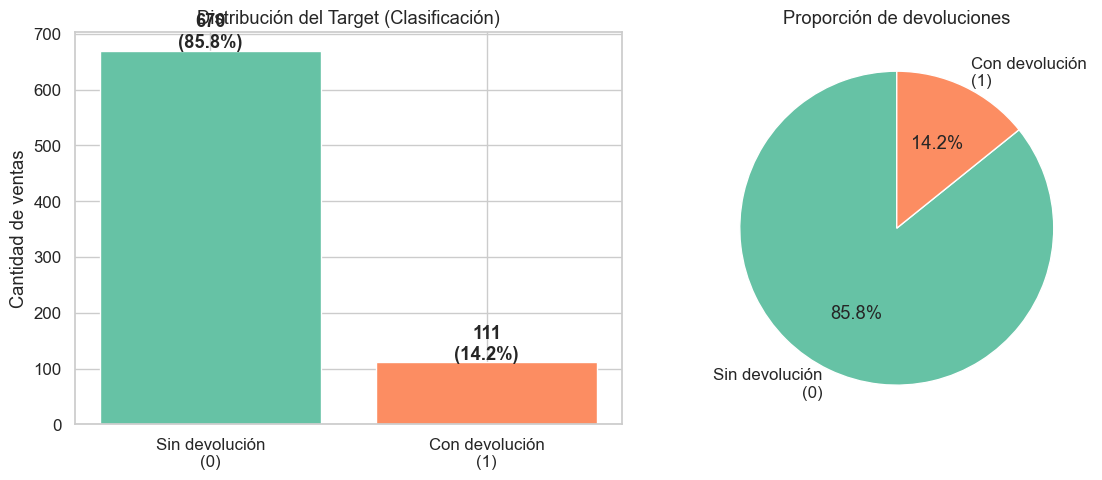


Desbalance: 6.0:1 (sin devolución : con devolución)
→ Se deberá aplicar técnicas de balanceo (class_weight='balanced' o SMOTE) en el modelado.


In [12]:
fig, axes = plt.subplots(1, 2, figsize=FIGSIZE)

# Conteo
conteo = df_ml['tiene_devolucion'].value_counts()
labels = ['Sin devolución\n(0)', 'Con devolución\n(1)']
colors = sns.color_palette('Set2', 2)
axes[0].bar(labels, conteo.values, color=colors)
axes[0].set_title('Distribución del Target (Clasificación)')
axes[0].set_ylabel('Cantidad de ventas')
for i, v in enumerate(conteo.values):
    axes[0].text(i, v + 5, f'{v}\n({v/len(df_ml)*100:.1f}%)', ha='center', fontweight='bold')

# Pie
axes[1].pie(conteo.values, labels=labels, autopct='%1.1f%%', colors=colors, startangle=90)
axes[1].set_title('Proporción de devoluciones')

plt.tight_layout()
plt.savefig('../results/plots/01_target_clasificacion.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nDesbalance: {conteo[0]/conteo[1]:.1f}:1 (sin devolución : con devolución)")
print("→ Se deberá aplicar técnicas de balanceo (class_weight='balanced' o SMOTE) en el modelado.")


### 5.3 Distribución del target de regresión: `total_venta`

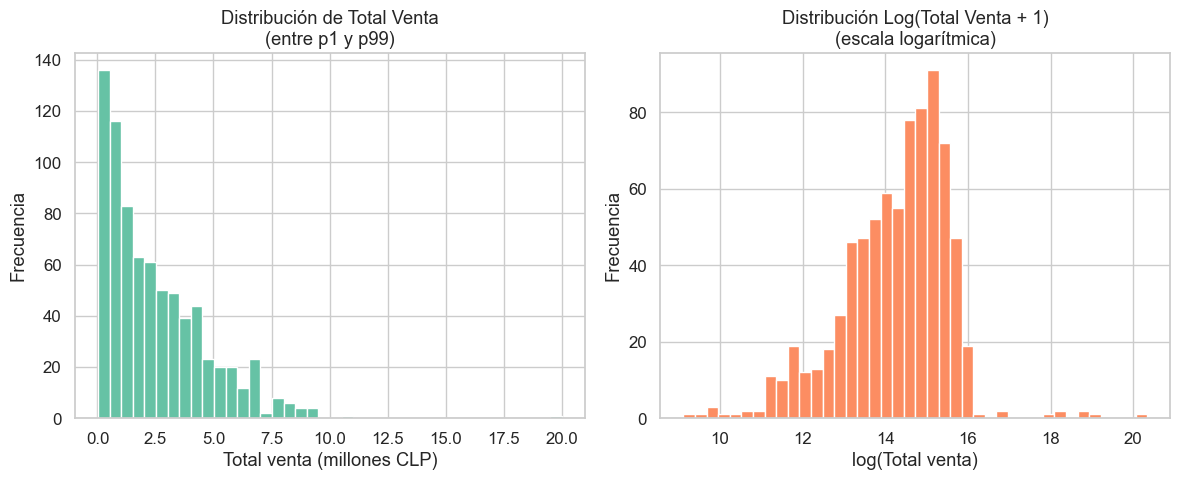

Total venta — Mediana: $1,922,240 | Media: $4,180,809
Outliers extremos (>p99): 8 filas
→ Para regresión se usará log(total_venta) como target para estabilizar la varianza.


In [13]:
# Filtrar outliers extremos para visualización (p1-p99)
p1  = df_ml['total_venta'].quantile(0.01)
p99 = df_ml['total_venta'].quantile(0.99)
df_vis = df_ml[(df_ml['total_venta'] >= p1) & (df_ml['total_venta'] <= p99)]

fig, axes = plt.subplots(1, 2, figsize=FIGSIZE)

axes[0].hist(df_vis['total_venta'] / 1e6, bins=40, color=sns.color_palette('Set2')[0], edgecolor='white')
axes[0].set_title('Distribución de Total Venta\n(entre p1 y p99)')
axes[0].set_xlabel('Total venta (millones CLP)')
axes[0].set_ylabel('Frecuencia')

# Log transform para ver la distribución real
log_tv = np.log1p(df_ml[df_ml['total_venta'] > 0]['total_venta'])
axes[1].hist(log_tv, bins=40, color=sns.color_palette('Set2')[1], edgecolor='white')
axes[1].set_title('Distribución Log(Total Venta + 1)\n(escala logarítmica)')
axes[1].set_xlabel('log(Total venta)')
axes[1].set_ylabel('Frecuencia')

plt.tight_layout()
plt.savefig('../results/plots/01_target_regresion.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Total venta — Mediana: ${df_ml['total_venta'].median():,.0f} | Media: ${df_ml['total_venta'].mean():,.0f}")
print(f"Outliers extremos (>p99): {(df_ml['total_venta'] > p99).sum()} filas")
print("→ Para regresión se usará log(total_venta) como target para estabilizar la varianza.")


### 5.4 Variables categóricas: distribución

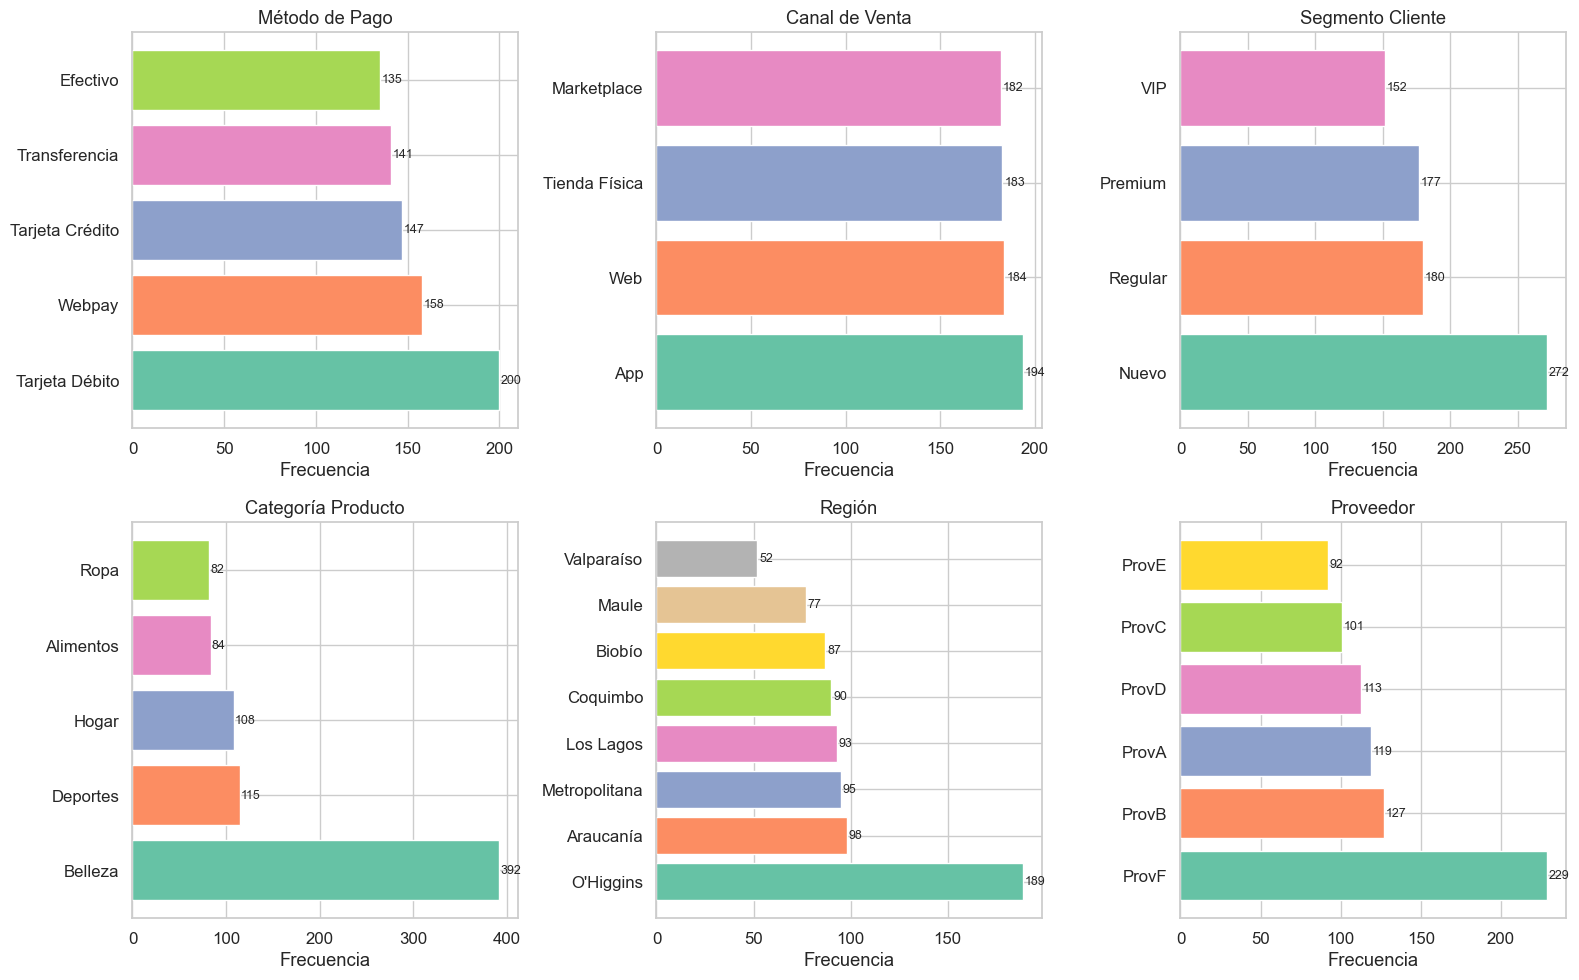

In [14]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

categoricas = [
    ('metodo_pago', 'Método de Pago'),
    ('canal_venta', 'Canal de Venta'),
    ('segmento', 'Segmento Cliente'),
    ('categoria', 'Categoría Producto'),
    ('region', 'Región'),
    ('proveedor', 'Proveedor'),
]

palette = sns.color_palette('Set2', 8)

for i, (col, titulo) in enumerate(categoricas):
    datos = df_ml[col].value_counts()
    axes[i].barh(datos.index, datos.values, color=palette[:len(datos)])
    axes[i].set_title(titulo)
    axes[i].set_xlabel('Frecuencia')
    for j, v in enumerate(datos.values):
        axes[i].text(v + 1, j, str(v), va='center', fontsize=9)

plt.tight_layout()
plt.savefig('../results/plots/01_categoricas.png', dpi=150, bbox_inches='tight')
plt.show()


### 5.5 Tasa de devolución por variable categórica

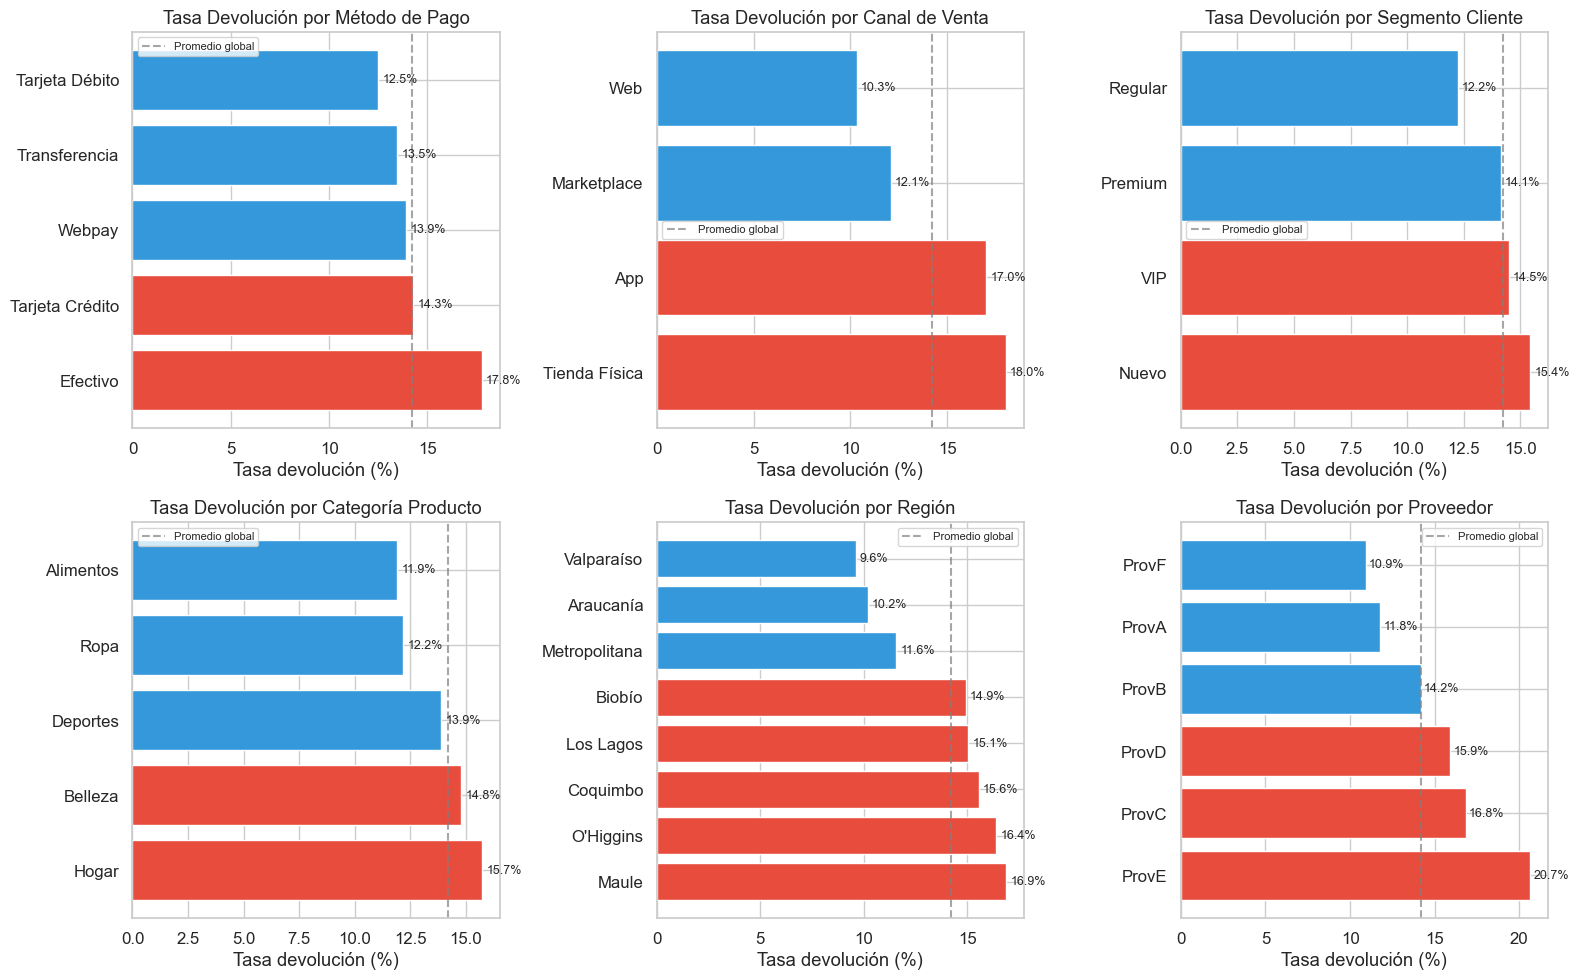

In [15]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, (col, titulo) in enumerate(categoricas):
    tasa = df_ml.groupby(col)['tiene_devolucion'].mean().sort_values(ascending=False)
    colors_bar = ['#e74c3c' if v > df_ml['tiene_devolucion'].mean() else '#3498db' for v in tasa.values]
    axes[i].barh(tasa.index, tasa.values * 100, color=colors_bar)
    axes[i].axvline(df_ml['tiene_devolucion'].mean() * 100, color='gray', linestyle='--', alpha=0.7, label='Promedio global')
    axes[i].set_title(f'Tasa Devolución por {titulo}')
    axes[i].set_xlabel('Tasa devolución (%)')
    axes[i].legend(fontsize=8)
    for j, v in enumerate(tasa.values):
        axes[i].text(v * 100 + 0.2, j, f'{v*100:.1f}%', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('../results/plots/01_tasa_devolucion_categoricas.png', dpi=150, bbox_inches='tight')
plt.show()


### 5.6 Análisis temporal

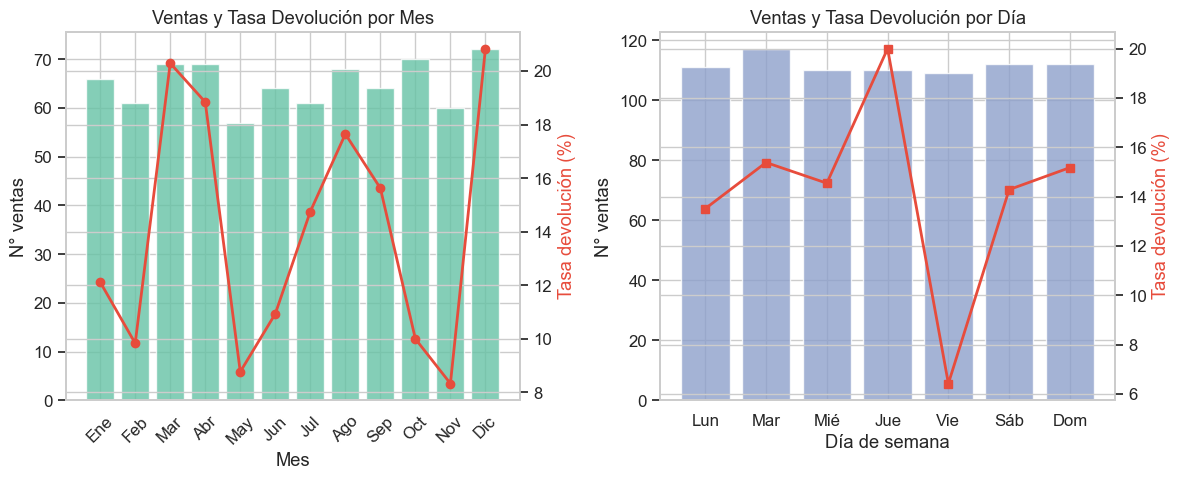

In [16]:
fig, axes = plt.subplots(1, 2, figsize=FIGSIZE)

# Ventas por mes
ventas_mes = df_ml.groupby('mes').agg(
    total_ventas=('id_venta', 'count'),
    tasa_devolucion=('tiene_devolucion', 'mean')
).reset_index()

meses = ['Ene','Feb','Mar','Abr','May','Jun','Jul','Ago','Sep','Oct','Nov','Dic']
ventas_mes['mes_nombre'] = ventas_mes['mes'].apply(lambda x: meses[x-1])

ax2 = axes[0].twinx()
axes[0].bar(ventas_mes['mes_nombre'], ventas_mes['total_ventas'], color=sns.color_palette('Set2')[0], alpha=0.8)
ax2.plot(ventas_mes['mes_nombre'], ventas_mes['tasa_devolucion']*100, 'o-', color='#e74c3c', linewidth=2)
axes[0].set_title('Ventas y Tasa Devolución por Mes')
axes[0].set_xlabel('Mes')
axes[0].set_ylabel('N° ventas')
ax2.set_ylabel('Tasa devolución (%)', color='#e74c3c')
axes[0].tick_params(axis='x', rotation=45)

# Ventas por día de semana
dias = ['Lun','Mar','Mié','Jue','Vie','Sáb','Dom']
ventas_dia = df_ml.groupby('dia_semana').agg(
    total_ventas=('id_venta', 'count'),
    tasa_devolucion=('tiene_devolucion', 'mean')
).reset_index()
ventas_dia['dia_nombre'] = ventas_dia['dia_semana'].apply(lambda x: dias[x])

ax4 = axes[1].twinx()
axes[1].bar(ventas_dia['dia_nombre'], ventas_dia['total_ventas'], color=sns.color_palette('Set2')[2], alpha=0.8)
ax4.plot(ventas_dia['dia_nombre'], ventas_dia['tasa_devolucion']*100, 's-', color='#e74c3c', linewidth=2)
axes[1].set_title('Ventas y Tasa Devolución por Día')
axes[1].set_xlabel('Día de semana')
axes[1].set_ylabel('N° ventas')
ax4.set_ylabel('Tasa devolución (%)', color='#e74c3c')

plt.tight_layout()
plt.savefig('../results/plots/01_temporal.png', dpi=150, bbox_inches='tight')
plt.show()


### 5.7 Correlación entre variables numéricas

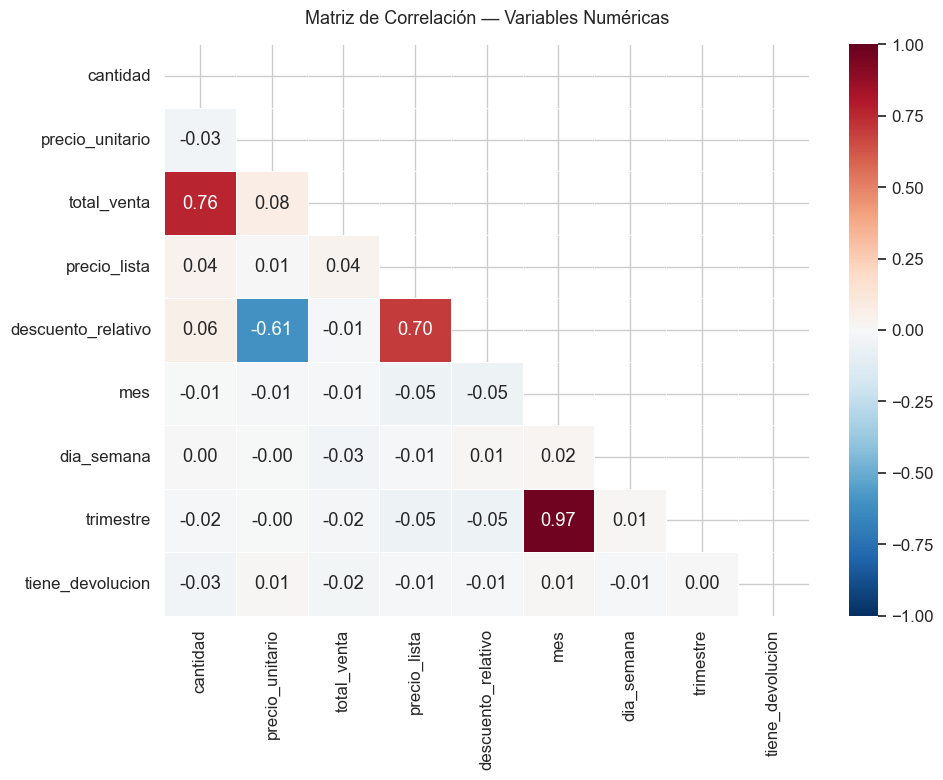

In [17]:
num_cols = ['cantidad', 'precio_unitario', 'total_venta', 'precio_lista',
            'descuento_relativo', 'mes', 'dia_semana', 'trimestre', 'tiene_devolucion']

corr = df_ml[num_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, ax=ax, linewidths=0.5)
ax.set_title('Matriz de Correlación — Variables Numéricas', fontsize=13, pad=15)
plt.tight_layout()
plt.savefig('../results/plots/01_correlacion.png', dpi=150, bbox_inches='tight')
plt.show()


### 5.8 Análisis de outliers en variables numéricas

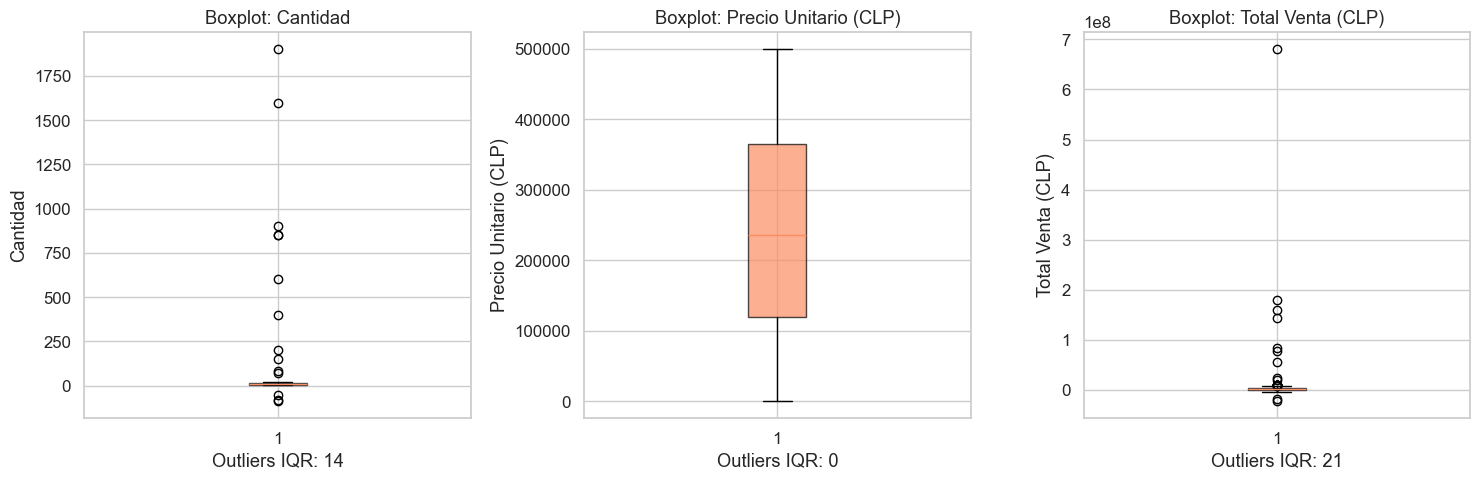

Decisión sobre outliers:
- 'cantidad' negativa (3 filas): eliminadas en limpieza (errores de registro).
- 'total_venta' extremos (>p99): se aplicará transformación log en regresión.
- Para clasificación: se mantendrán ya que pueden ser señal de devolución.


In [18]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
cols_out = ['cantidad', 'precio_unitario', 'total_venta']
labels_out = ['Cantidad', 'Precio Unitario (CLP)', 'Total Venta (CLP)']

for i, (col, lbl) in enumerate(zip(cols_out, labels_out)):
    axes[i].boxplot(df_ml[col].dropna(), vert=True, patch_artist=True,
                    boxprops=dict(facecolor=sns.color_palette('Set2')[i], alpha=0.7))
    axes[i].set_title(f'Boxplot: {lbl}')
    axes[i].set_ylabel(lbl)
    q1 = df_ml[col].quantile(0.25)
    q3 = df_ml[col].quantile(0.75)
    iqr = q3 - q1
    outliers = ((df_ml[col] < q1 - 1.5*iqr) | (df_ml[col] > q3 + 1.5*iqr)).sum()
    axes[i].set_xlabel(f'Outliers IQR: {outliers}')

plt.tight_layout()
plt.savefig('../results/plots/01_outliers.png', dpi=150, bbox_inches='tight')
plt.show()

# Decisión sobre outliers
print("Decisión sobre outliers:")
print("- 'cantidad' negativa (3 filas): eliminadas en limpieza (errores de registro).")
print("- 'total_venta' extremos (>p99): se aplicará transformación log en regresión.")
print("- Para clasificación: se mantendrán ya que pueden ser señal de devolución.")


---
## 6. Resumen del EDA y Decisiones para el Modelado


In [19]:
print("="*60)
print("RESUMEN EDA — DATASET MAESTRO")
print("="*60)
print(f"Filas finales:          {len(df_ml):,}")
print(f"Features disponibles:   {df_ml.shape[1] - 2} (excl. targets)")
print()
print("TARGET CLASIFICACIÓN: 'tiene_devolucion'")
tasa = df_ml['tiene_devolucion'].mean()
print(f"  Clase 0 (sin dev.):  {(df_ml['tiene_devolucion']==0).sum()} ({1-tasa:.1%})")
print(f"  Clase 1 (con dev.):  {(df_ml['tiene_devolucion']==1).sum()} ({tasa:.1%})")
print(f"  → Dataset desbalanceado. Usar class_weight='balanced' o SMOTE.")
print()
print("TARGET REGRESIÓN: 'total_venta'")
print(f"  Rango: ${df_ml['total_venta'].min():,.0f} → ${df_ml['total_venta'].max():,.0f}")
print(f"  → Distribución sesgada a la derecha. Usar log(total_venta) como target.")
print()
print("FEATURES SELECCIONADAS PARA MODELADO:")
features = ['cantidad', 'precio_unitario', 'mes', 'dia_semana', 'trimestre',
            'descuento_relativo', 'metodo_pago', 'canal_venta', 'segmento',
            'categoria', 'region', 'proveedor']
for f in features:
    print(f"  - {f}")
print()
print("PRÓXIMO PASO: 02_supervised_modeling.ipynb")


RESUMEN EDA — DATASET MAESTRO
Filas finales:          781
Features disponibles:   17 (excl. targets)

TARGET CLASIFICACIÓN: 'tiene_devolucion'
  Clase 0 (sin dev.):  670 (85.8%)
  Clase 1 (con dev.):  111 (14.2%)
  → Dataset desbalanceado. Usar class_weight='balanced' o SMOTE.

TARGET REGRESIÓN: 'total_venta'
  Rango: $-21,582,990 → $679,798,400
  → Distribución sesgada a la derecha. Usar log(total_venta) como target.

FEATURES SELECCIONADAS PARA MODELADO:
  - cantidad
  - precio_unitario
  - mes
  - dia_semana
  - trimestre
  - descuento_relativo
  - metodo_pago
  - canal_venta
  - segmento
  - categoria
  - region
  - proveedor

PRÓXIMO PASO: 02_supervised_modeling.ipynb


In [20]:
# Guardar dataset ML limpio para uso en notebooks siguientes
import os
os.makedirs('../data', exist_ok=True)
df_ml.to_csv('../data/dataset_ml.csv', index=False, encoding='utf-8')
print("✓ Dataset ML guardado en data/dataset_ml.csv")
print(f"  Shape: {df_ml.shape}")


✓ Dataset ML guardado en data/dataset_ml.csv
  Shape: (781, 19)
